In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 6,                # reduced for small figure
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": 0.5,
    "lines.linewidth": 0.6,
    "legend.fontsize": 5.5,
    "legend.title_fontsize": 5.5,
    "xtick.major.size": 2,
    "ytick.major.size": 2,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "pdf.fonttype": 42,            # ensures editable text in Illustrator
    "ps.fonttype": 42
})


def make_fixed_axis(axis_size=1.25, label_space=0.15):
    """Create figure with a fixed physical data-area size."""
    figsize = (axis_size + label_space, axis_size + label_space)
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = fig.add_gridspec(1, 1)
    ax = fig.add_subplot(gs[0, 0])
    ax.set_box_aspect(1)  # ensures square data region
    return fig, ax

In [18]:
def get_gamma_G1_G2(frac, rep):

    address = r"C:\Users\ayantis\Desktop\PhD\Research\Project 1 - Formation of a swelling gel underlies a morphological transition in Bacillus subtilis biofilms\PNAS submission\Revision\Review experiments\Review expt #1\EPS "+str(frac)+"\EPS "+str(frac)+" n="+str(rep)+".xls"
    file = pd.read_excel(address, sheet_name = "Amplitude sweep - 1", header = 1, skiprows = 0)
    G1 = file["Storage modulus"][1:]
    G2 = file["Loss modulus"][1:]
    gamma = file["Oscillation strain"][1:]
    
    return gamma, G1, G2

In [19]:
gammas = []
G1s = []

for i in range(1, 4):
    g, g1, g2 = get_gamma_G1_G2(frac=100, rep=i)

    gammas.append(np.array(g, dtype=float))
    G1s.append(np.array(g1, dtype=float))

gammas_arr = np.array(gammas)
G1s_arr = np.array(G1s)

mean_G1_100 = np.mean(G1s_arr, axis=0)
std_G1_100 = np.std(G1s_arr, axis=0)
x_axis_100 = gammas[-1]

In [20]:
gammas = []
G1s = []

for i in range(1, 4):
    g, g1, g2 = get_gamma_G1_G2(frac=75, rep=i)
    gammas.append(np.array(g, dtype=float))
    G1s.append(np.array(g1, dtype=float))

gammas_arr = np.array(gammas)
G1s_arr = np.array(G1s)
mean_G1_75 = np.mean(G1s_arr, axis=0)
std_G1_75 = np.std(G1s_arr, axis=0)
x_axis_75 = gammas[0]

In [21]:

gammas = []
G1s = []

for i in range(1, 4):
    g, g1, g2 = get_gamma_G1_G2(frac=50, rep=i)
    gammas.append(np.array(g, dtype=float))
    G1s.append(np.array(g1, dtype=float))

gammas_arr = np.array(gammas)
G1s_arr = np.array(G1s)
mean_G1_50 = np.mean(G1s_arr, axis=0)
std_G1_50 = np.std(G1s_arr, axis=0)
x_axis_50 = gammas[0]

In [22]:
gammas = []
G1s = []

for i in range(1, 4):
    g, g1, g2 = get_gamma_G1_G2(frac=25, rep=i)
    gammas.append(np.array(g, dtype=float))
    G1s.append(np.array(g1, dtype=float))

gammas_arr = np.array(gammas)
G1s_arr = np.array(G1s)
mean_G1_25 = np.mean(G1s_arr, axis=0)
std_G1_25 = np.std(G1s_arr, axis=0)
x_axis_25 = gammas[0]

In [23]:


gammas = []
G1s = []

for i in range(2, 3):
    g, g1, g2 = get_gamma_G1_G2(frac=0, rep=i)
    gammas.append(np.array(g, dtype=float))
    G1s.append(np.array(g1, dtype=float))

gammas_arr = np.array(gammas)
G1s_arr = np.array(G1s)
mean_G1_0 = np.mean(G1s_arr, axis=0)
std_G1_0 = np.std(G1s_arr, axis=0)
x_axis_0 = gammas[0]

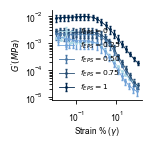

In [24]:
fig, ax = make_fixed_axis()

colors = ['#add8e6', '#70a1d7', '#4876a4', '#264d73', '#00264d']

data_list = [
    (x_axis_0, mean_G1_0, std_G1_0, r"$f_{EPS}=0$"),
    (x_axis_25, mean_G1_25, std_G1_25, r"$f_{EPS}=0.25$"),
    (x_axis_50, mean_G1_50, std_G1_50, r"$f_{EPS}=0.50$"),
    (x_axis_75, mean_G1_75, std_G1_75, r"$f_{EPS}=0.75$"),
    (x_axis_100, mean_G1_100, std_G1_100, r"$f_{EPS}=1$")
]

for i, (x, y, yerr, lab) in enumerate(data_list):
    plt.errorbar(x, y, yerr=yerr, fmt='o-', markersize=1, 
                 color=colors[i], capsize=1, elinewidth=1, label=lab)

ax.set_xlabel(r'Strain % ($\gamma$)', labelpad=1)
ax.set_ylabel(r"$G^{'} (MPa)$", labelpad=1)
ax.set_xscale('log')
ax.set_yscale('log')

ax.tick_params(axis='both', which='major', length=3, direction='out', width=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)

ax.legend(frameon=False, loc='best')
plt.savefig(r"C:\Users\ayantis\Desktop\PhD\Research\Project 1 - Formation of a swelling gel underlies a morphological transition in Bacillus subtilis biofilms\PNAS submission\Revision\Review experiments\Review expt #1\G' amplitude sweep.svg", format = "svg", dpi = 600, bbox_inches = "tight")
plt.show()



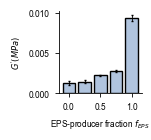

In [25]:
fig, ax = make_fixed_axis()
G1_0_LVR  = np.mean(mean_G1_0[0:8])
G1_25_LVR  = np.mean(mean_G1_25[0:8])
G1_50_LVR  = np.mean(mean_G1_50[0:8])
G1_75_LVR  = np.mean(mean_G1_75[0:8])
G1_100_LVR  = np.mean(mean_G1_100[0:8])

G1_0_LVR_std  = np.std(mean_G1_0[0:8])
G1_25_LVR_std  = np.std(mean_G1_25[0:8])
G1_50_LVR_std  = np.std(mean_G1_50[0:8])
G1_75_LVR_std  = np.std(mean_G1_75[0:8])
G1_100_LVR_std  = np.std(mean_G1_100[0:8])

G1_LVR = np.array([G1_0_LVR, G1_25_LVR, G1_50_LVR, G1_75_LVR, G1_100_LVR])

G1_LVR_std = np.array([G1_0_LVR_std, G1_25_LVR_std, G1_50_LVR_std, G1_75_LVR_std, G1_100_LVR_std])

fractions = np.array([0, 0.25, 0.50, 0.75, 1])
ax.bar(fractions, G1_LVR, yerr = G1_LVR_std , width=0.2, color='lightsteelblue', edgecolor='black', capsize=1)

ax.set_xlabel(r'EPS-producer fraction $f_{EPS}$')
ax.set_ylabel(r"$G^{'} (MPa)$")
ax.tick_params(axis='both', which='major', length=3, direction='out', width=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.6)
ax.spines['bottom'].set_linewidth(0.6)

# plt.savefig(r"C:\Users\ayantis\Desktop\PhD\Research\Project 1 - Formation of a swelling gel underlies a morphological transition in Bacillus subtilis biofilms\PNAS submission\Revision\Review experiments\Review expt #1\G' vs f_EPS.svg", format = "svg", dpi = 600)
plt.show()


--- FIT PARAMETERS ---
Prefactor (A):         0.0456 ± 0.0067
Scaling Exponent (mu): 4.69 ± 0.90

--- GOODNESS OF FIT METRICS ---
Residual Standard Error (RSE): 0.0015 MPa


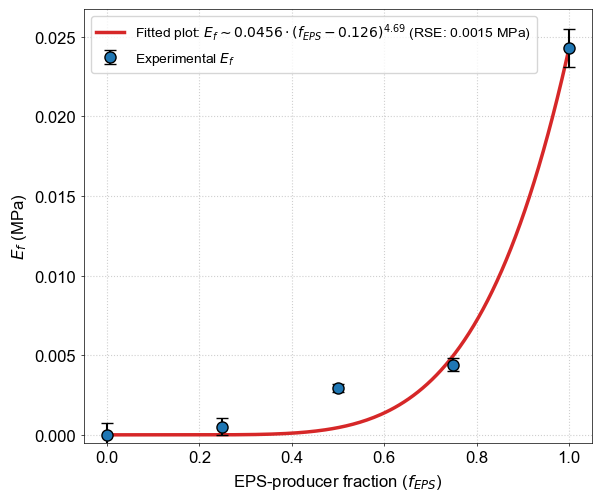

In [31]:
# --- 1. Experimental Arrays ---
f_EPS = np.array([0.0, 0.25, 0.50, 0.75, 1.0])
G1_LVR = np.array([0.00125818, 0.00142925, 0.00224673, 0.00272787, 0.00935836])
Ef = 3 * G1_LVR
Ef_err = 3 * G1_LVR_std
B = Ef[0]
Ef = Ef-B
f_c = 0.126

# --- 2. Define the Piecewise Percolation Model ---
def percolation_model(f, A, mu):
    """
    G' = A * (f_EPS - f_c)^mu + B for f_EPS > f_c
    G' = B                        for f_EPS <= f_c
    """
   
    # np.maximum(0, f - f_c) protects against negative bases and clears the RuntimeWarning
    g_prime = A * (np.maximum(0, f - f_c) ** mu) 
    return np.where(f > f_c, g_prime, 0)

# --- 3. Perform the Fit ---
initial_guess = [0.01, 2.0]
bounds = ((0, 0.5), (np.inf, 10.0))

popt, pcov = curve_fit(percolation_model, f_EPS, Ef, p0=initial_guess, bounds=bounds)
A_fitted, mu_fitted = popt
perr = np.sqrt(np.diag(pcov))

# --- 4. Recalculate Goodness of Fit ---
predictions = percolation_model(f_EPS, A_fitted, mu_fitted)
residuals = Ef - predictions

rss = np.sum(residuals**2)
tss = np.sum((Ef - np.mean(Ef))**2)
r_squared = 1 - (rss / tss)

n = len(f_EPS)  
p = len(popt)   
dof = n - p     

adj_r_squared = 1 - ((1 - r_squared) * (n - 1) / dof)
rse = np.sqrt(rss / dof)

# --- 5. Print Results ---
print("--- FIT PARAMETERS ---")
print(f"Prefactor (A):         {A_fitted:.4f} \u00b1 {perr[0]:.4f}")
print(f"Scaling Exponent (mu): {mu_fitted:.2f} \u00b1 {perr[1]:.2f}")

print("\n--- GOODNESS OF FIT METRICS ---")
print(f"Residual Standard Error (RSE): {rse:.4f} MPa")

# --- 6. Plotting ---
f_smooth = np.linspace(0.0, 1.0, 200)
G_smooth = percolation_model(f_smooth, A_fitted, mu_fitted)

plt.figure(figsize=(6, 5), tight_layout=True)
plt.errorbar(f_EPS, Ef, yerr=Ef_err, fmt='o', color='#1f77b4', mec='k', mfc='#1f77b4', 
             ms=8, ecolor='k', elinewidth=1.5, capsize=4, zorder=3, label="Experimental $E_f$")
plt.plot(f_smooth, G_smooth, color='#d62728', linestyle='-', linewidth=2.5, 
         label=rf'Fitted plot: $E_f\sim {A_fitted:.4f} \cdot (f_{{EPS}} - {f_c:.3f})^{{{mu_fitted:.2f}}}$ (RSE: {rse:.4f} MPa)')
plt.xlabel('EPS-producer fraction ($f_{EPS}$)', fontsize=12)
plt.ylabel("$E_f$ (MPa)", fontsize=12)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.0005, max(Ef) * 1.1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, fontsize = 10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [12]:
B/A_fitted


0.08280050171342661